# Class 18: Random Numbers 

Ch. 10, section 1: Random number generators & probabilities 

- Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

## Random Numbers

#### Linear congruential random number generator

Let's program and use this random number generator

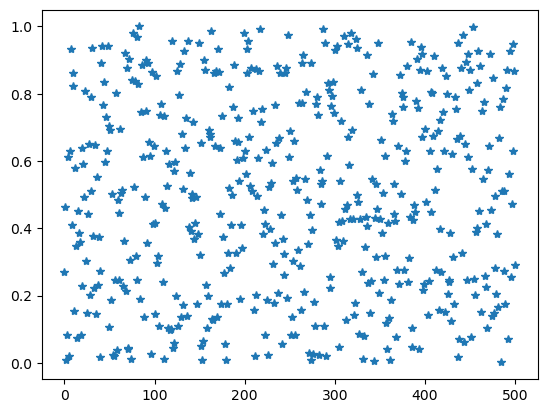

In [30]:
def rand(x,N=1,a=166425,c=1013904223,m=4294967296):
    list = []
    for i in range(N+1):
        x = (a*x+c)%m
        list.append(x)
    return np.array(list,float)
seed = 886
N = 500

R1_list = rand(seed,N)
R1_list = R1_list/np.max(R1_list)

plt.plot(R1_list, "*")

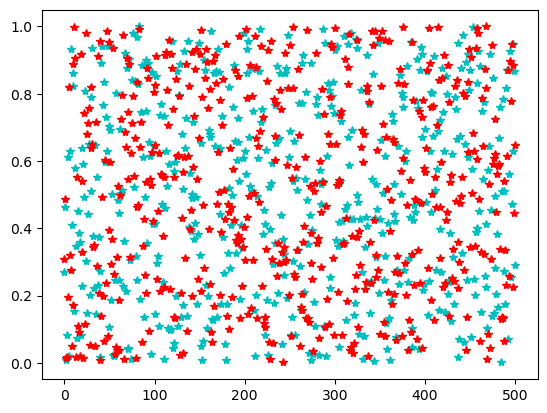

In [33]:
def rand(x,N=1,a=166425,c=1013904223,m=4294967296):
    list = []
    for i in range(N+1):
        x = (a*x+c)%m
        list.append(x)
    return np.array(list,float)
seed = 1234567890
N = 500

R2_list = rand(seed,N)
R2_list = R2_list/np.max(R2_list)

plt.plot(R1_list, "*c")
plt.plot(R2_list, "*r")

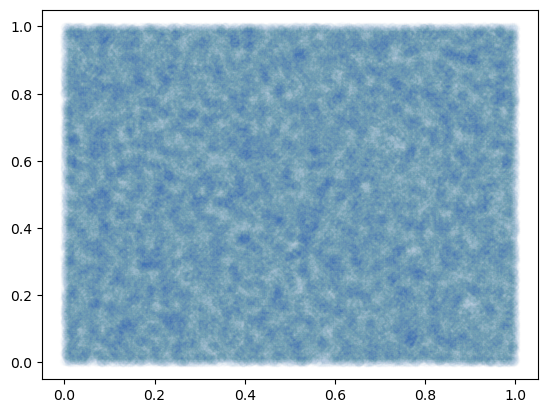

In [ ]:
seed = 7483091
N = 100000

R3_list = rand(seed,N)
R3_list = R3_list/np.max(R3_list)
R4_list = rand(seed-1,N)
R4_list = R4_list/np.max(R4_list)

plt.scatter(R3_list,R4_list, alpha=0.01)
#Noise mappish!

### Python random package - Mersenne Twister Generator

Let's use the random package instead 
- try out different seeds to see how the results compare

In [92]:
x = random.random()
y = random.random()
print(x,y)

a = random.randrange(50)
print(a)

b = random.randrange(1,2,3) # 1 to 2, 1 is included, 4 is not ... always 1
print(b)

0.7863676058595256 0.8356848291953636
26
1


## Probabilities and biased coins

Let's flip a coin and count how many times we get heads vs. tails

*twist* let's bias the coin so that 1/5th of the time only we get heads

In [112]:
N = 100
T = 0
random_list = [random.random() for i in range(N)]
for r in random_list:
    if r<0.5:
        T+=1
H = N-T
print("Head Count:", H, "Heads")
print("Tail Count:", T, "Tails")

#Biased:
Tb = 0
r_biased_list = [random.random() for i in range(N)]
for r in r_biased_list:
    if r<0.8:
        Tb+=1
Hb = N-Tb
print("Head Count:", Hb, "Heads")
print("Tail Count:", Tb, "Tails")

#In generality:
def Coin_flipper(N=1,Chnc_Head=0.5):
    Heads = 0
    Coins = [random.random() for i in range(N)]
    for i in Coins:
        if r<Chnc_Head:
            Heads+=1
    return [Heads,N - Heads]

Coin_results = Coin_flipper(100,0.2)
Hg,Tg = Coin_results
print("Head Count:", Hg, "Heads")
print("Tail Count:", Tg, "Tails")


Head Count: 63 Heads
Tail Count: 37 Tails
Head Count: 24 Heads
Tail Count: 76 Tails
Head Count: 0 Heads
Tail Count: 100 Tails


#### Example 10.1 decay of an isotope 

The radioisotope $^{208}Tl$ (thallium 208) decays to stable $^{208}Pb$ (lead 208) with a half-life of 3.053 minutes. Suppose we start with a sample of 1000 thallium atoms. Let us simulate the decay of these atoms over time, mimicking the randomness of that decay using random numbers. 

On average, we know that the number $N$ of atoms in our sample will fall off exponentially over time according to the standard equation of radioactive decay: 
$$ N(t) = N(0)2^{-t/\tau}$$
where $\tau$ is the half-life. Then the fraction of atoms remaining after time $t$ is $N(t)/N(0) = 2^{-t/\tau}$ and the fraction that have decayed, which is also equal to the probability $p(t)$ that any particular single atom has decayed, is one minus this number or
$$ p(t) = 1-2^{-t/\tau}$$
Thus this number represents the probability that a single atom decays in a time interval of length $t$. 

We will simulate the decay of our sample of 1000 atoms by dividing the atoms in two sets, one of thallium and one of lead. Initially all the atoms are in the thallium set. We will divide time into time-steps of 1 second each and in each time-step we will consider in turn each thallium atom and with the probability given in the equation decide whether or not it decays. In this way we work out the total number of tallium atoms that decay in each second, then we subtract this number from the total in the thallium set and add it to the total in the lead set. 

Let's do this for 1000 seconds and plot how the number of atoms of each type changes with time. 

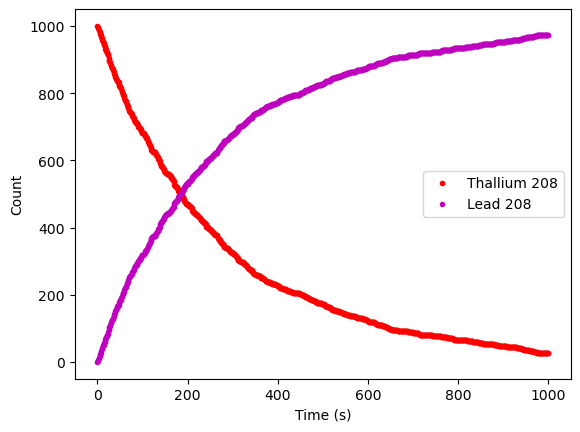

In [126]:
#Functions:
def N(t): #
    return N_Tl*2**(-t/tau)
def p(t): #Decay probability
    return 1 - 2**(-t/tau)

#Constants:
N_Tl  = 1000
N_Pb = 0
tau  = 3.053*60

#time
h = 1
t_i, t_f = 0, 1000

# Probability of decay:
P = p(h)


# arrays
t_array = np.arange(t_i,t_f+h,h)
Tl_array = np.zeros(len(t_array))
Pb_array = np.zeros(len(t_array))

#loop
for i in range(len(t_array)):
    Tl_array[i], Pb_array[i] = N_Tl, N_Pb
    Change = 0
    for i in range(N_Tl):
        r = random.random()
        if r<P:
            Change+=1
    N_Pb += Change
    N_Tl -= Change
    # Coin_flipper(Count, Chance of decay) = (Decayed, Remaining)

plt.plot(Tl_array, "r.")
plt.plot(Pb_array, "m.")
plt.xlabel("Time (s)")
plt.ylabel("Count")
plt.legend(["Thallium 208", "Lead 208"])
plt.show()


## Nonuniform Numbers 

generate random real numbers 𝑥 in the interval from zero to infinity with the exponential probability distribution: 
$$ p(x) =\mu e^{−\mu x}$$

We found from the transformation method that we need to use: 

$$x = -\frac{1}{\mu} \ln (1-z)$$

where $\mu = \ln 2/\tau$

#### Example 10.2: Rutherford Scattering 

At the beginning of the 20th centurey, Ernest Rutherford and his collaborators showed that when an $alpha$ partiles, i.e. a helium nucleius of two protons and two neutrons, passes close to an atom as shown in the figure, it is scattered, primarily by electrical repulsion from the positively charged nucleus of the atoms, and that the angle $\theta$ through which it is scattered obeys
$$ \tan \frac{1}{2}\theta = \frac{Ze^2}{2\pi \epsilon_0 Eb} $$

where $Z$ is the atomic number of the nucelus, $e$ is the electron charge, $\epsilon_0$ is the permittivity of free space, $E$ is the kinetic energy of the incident $\alpha$ particle, and $b$ is the impact parameter, i.e., the perpendicular distance between the particle's initial trajectory and the axis running through the nucelus. 

Consdier a beam of particles with energy 7.7 MeV that has a Gaussian profile in both is $x$ and $y$ axes with standard deviation $\sigma = a_0/100$, where $a_0$ is the Bohr radius. The beam is fired directly at a gold atom. Let us simulate the scattering process for one million $\alpha$ particles and calculate the fraction of particles that "bounce back" on scattering, i.e., that scatter through angles greater than $90\degree$. The threshold value of the impact parameter for which this happens can be calculated from Eq. 10.19 with $\theta = 90\degree$, which gives
$$b = \frac{Ze^2}{2\pi\epsilon_0E}$$
If $b$ is less than this value then the particle bounces back. 